In [2]:
from __future__ import annotations
from pathlib import Path 

import yaml, json, os, sys

import numpy as np, matplotlib.pyplot as plt
import igraph as ig, networkx as nx
import torch

from collections import deque 
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.colors as mcolors


ROOT = "/scratch/sleonard/MoE_circuits"
sys.path.insert(0, ROOT)

with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

/scratch/sleonard/miniconda3/envs/megatron/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
MODELS   = ["olmoe", "deepseek-v2-lite"]
# MODELS   = ["olmoe", "deepseek-v2-lite", "mixtral-8x7b", "mixtral-8x22b", "qwen3-30b-a3b", "phi-3.5-moe", "qwen3-235b-a22b"]
DATASETS = ["c4"]
# DATASETS = ["c4", "math", "code"]

dags: dict[tuple[str, str], dict] = {}
for m in MODELS:
    for d in DATASETS:
        path = os.path.join(config["result_path"], f"circuits/dag_{m}_{d}.pt")
        dags[(m, d)] = torch.load(path, map_location="cpu")


In [ ]:
from experiments.circuits.helper import get_thresholds, thresholding_routing_graph, show_enhanced_layered_graph
# 'APS', 'ANS', 'AVG', 'VAR', 'AARV', 'ARV', 'P_add', 'P_rem', 'n_tokens_selected', 'top_weight', 'top_prompt', 'top_pos', 'top_token', 'k_top_tokens', 'n_prompts', 'max_tokens', 'model', 'moe_layers', 'dataset'])

# Super-expert-paper double criterion for edge thresholding (per-model, no Q knob):
#   keep edge iff |W| >= P_99.5(|W|)  AND  |W| >= max(|W|) / 10.
# "X >= A AND X >= B"  iff  "X >= max(A, B)".
TARGET = "APS"
for d in DATASETS:
    for m in MODELS:
        dag = dags[(m, d)]
        W = dag[TARGET]
        L = W.shape[0]
        s_idx = torch.arange(L).view(-1, 1, 1, 1)
        r_idx = torch.arange(L).view(1, 1, -1, 1)
        valid = torch.abs(W[(s_idx < r_idx).expand_as(W)].float())
        valid = valid[valid > 1e-9].cpu().numpy()
        t = max(float(np.quantile(valid, 0.995)), float(valid.max()) / 10.0)
        # Effective percentile of the threshold (for the plot title only).
        eff_q = float((valid <= t).mean())
        g = thresholding_routing_graph(dag, TARGET, t)
        show_enhanced_layered_graph(g, quantile=eff_q, target=TARGET, model=m, dataset=d, n_prompts=dag["n_prompts"])

In [9]:
# --- Layer-pair mass (LPM) fingerprint with RANK-TRANSFORMED weights ---
# Cross-architecture scale issue: raw AARV magnitudes are bounded by
# (N_EXPERTS - 1), so a value of "2" in Mixtral (8 experts -> max 7) means a
# very different thing than in Qwen3-235B (128 experts -> max 127). Rank
# transform replaces each edge's |W| with its percentile rank in the model's
# own forward-edge distribution; afterward every model's edge values are
# uniform on (0, 1] regardless of architecture.
#
# Note: Dividing by (N_EXPERTS - 1) is a NO-OP because LPM normalizes bucket
# masses per-DAG; only the rank transform actually changes the analysis by
# removing distributional-shape differences (not just scale).
from experiments.circuits.helper import get_thresholds, layer_pair_mass, lpm_similarity
from scipy.stats import rankdata

WEIGHT, Q, N_BUCKETS = "AARV", 0.99, 12

def rank_transform(W):
    """Replace each forward-edge (s<r, |W|>0) entry's value with its percentile
    rank within the DAG's own distribution. Output values in (0, 1]."""
    W = W.cpu().numpy().astype(np.float64) if hasattr(W, "cpu") else np.asarray(W, dtype=np.float64)
    L = W.shape[0]
    s_idx = np.arange(L).reshape(-1, 1, 1, 1)
    r_idx = np.arange(L).reshape(1, 1, -1, 1)
    fwd = np.broadcast_to(s_idx < r_idx, W.shape)
    valid = fwd & (np.abs(W) > 1e-9)
    vals = np.abs(W[valid])
    if vals.size == 0:
        return np.zeros_like(W)
    ranks = rankdata(vals, method="average") / vals.size
    out = np.zeros_like(W)
    out[valid] = ranks
    return out

M_dict = {}
for key, dag in dags.items():
    W = rank_transform(dag[WEIGHT])
    # After rank transform, valid ranks are uniform on (0, 1].
    # Threshold at Q directly (the q-quantile of a uniform[(0,1]] is just q).
    Ws = np.where(W >= Q, W, 0.0)
    M_dict[key] = layer_pair_mass(Ws, n_buckets=N_BUCKETS)


# # Grid: rows = models, cols = datasets.
# fig, axes = plt.subplots(len(MODELS), len(DATASETS), figsize=(11, 3.5 * len(MODELS)))
# vmax = max(M.max() for M in M_dict.values())
# for i, m in enumerate(MODELS):
#     for j, d in enumerate(DATASETS):
#         ax = axes[i, j] if len(MODELS) > 1 else axes[j]
#         im = ax.imshow(M_dict[(m, d)], cmap="viridis", origin="upper", vmin=0, vmax=vmax)
#         ax.set_title(f"{m}/{d}", fontsize=10)
#         ax.set_xticks(range(N_BUCKETS)); ax.set_yticks(range(N_BUCKETS))
#         ax.set_xlabel("receiver bucket (r/L)")
#         ax.set_ylabel("sender bucket (s/L)")
#         fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# fig.suptitle(f"LPM fingerprint (RANK-transformed {WEIGHT}, K={N_BUCKETS}, q={Q})")
# plt.tight_layout(); plt.show()

TypeError: 'Axes' object is not subscriptable

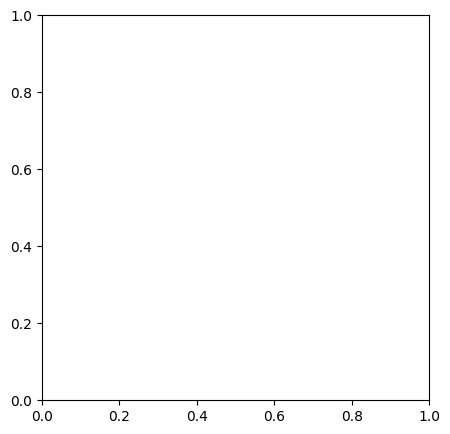

In [10]:
# --- 21x21 BRD cosine similarity matrix + pairwise cross-model aggregates ---
# Restricted to softmax+L1-normalized routing architectures (consistent application
# of the score decomposition framework).

n, m = len(MODELS), len(DATASETS)
BRD_COS = np.zeros((m, n, n))
for d, task in enumerate(DATASETS): 
    for i, m1 in enumerate(MODELS): 
        for j, m2 in enumerate(MODELS):  
            BRD_COS[d, i, j] = lpm_similarity(M_dict[(m1, task)], M_dict[(m2, task)], metric="cosine")


fig, axs = plt.subplots(1, m, figsize=(5*m, 5))
for d, task in enumerate(DATASETS): 
    ax = axs[d]
    ax.set_title(f"{task}")
    im = ax.imshow(BRD_COS[d,:,:], cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(MODELS, rotation=45, ha="right") 
    ax.set_yticklabels(MODELS)

    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{BRD_COS[d, i, j]:.2f}", ha="center", va="center", color="white" if BRD_COS[d, i, j] < 0.5 else "black", fontsize=10)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Cosine Similarity ({WEIGHT}, q={Q})")
plt.tight_layout()
plt.show()


# Block aggregates: within-model (task stability) + pairwise cross-model.
# def block_mean(M, rows, cols, exclude_diag=False):
#     vals = [M[i, j] for i in rows for j in cols if not (exclude_diag and i == j)]
#     return float(np.mean(vals)) if vals else float("nan")

# model_idx = {m: [i for i, k in enumerate(keys) if k[0] == m] for m in MODELS}

# print(f"--- BRD cosine  (K={N_BUCKETS}, sparsified {WEIGHT}, q={Q}) ---")
# print("  Within-model (task stability):")
# for m in MODELS:
#     wm = block_mean(BRD_COS, model_idx[m], model_idx[m], exclude_diag=True)
#     print(f"    WM[{m:<18s}] = {wm:.3f}")
# print("  Cross-model (CMS = same-dataset, CMD = different-dataset):")
# pairs = [(MODELS[a], MODELS[b]) for a in range(len(MODELS)) for b in range(a + 1, len(MODELS))]
# for m_a, m_b in pairs:
#     idx_a, idx_b = model_idx[m_a], model_idx[m_b]
#     CMS = float(np.mean([BRD_COS[i, j] for i in idx_a for j in idx_b if keys[i][1] == keys[j][1]]))
#     CMD = float(np.mean([BRD_COS[i, j] for i in idx_a for j in idx_b if keys[i][1] != keys[j][1]]))
#     print(f"    {m_a:<18s} <-> {m_b:<18s}  CMS={CMS:.3f}  CMD={CMD:.3f}")

In [ ]:
# # --- Sparsification sweep: how do cross-model alignment + task stability vary with Q? ---
# # Diagnostic for metric robustness. If pair rankings reorder dramatically as Q varies,
# # the LPM metric is unreliable as a similarity measure. If curves are roughly parallel
# # across a wide Q range, that's the stable regime we should report.
# Q_VALUES = [0.5, 0.8, 0.9, 0.95, 0.99, 0.999, 0.9999]

# pair_keys = [(MODELS[a], MODELS[b]) for a in range(len(MODELS)) for b in range(a + 1, len(MODELS))]
# CMS_curves = {p: [] for p in pair_keys}
# CMD_curves = {p: [] for p in pair_keys}
# WM_curves  = {m: [] for m in MODELS}

# for Q_s in Q_VALUES:
#     M_dict_s = {}
#     for key, dag in dags.items():
#         W = dag[WEIGHT]
#         if isinstance(W, torch.Tensor):
#             W = W.cpu().numpy().astype(np.float64)
#         t = get_thresholds(dag, WEIGHT, [Q_s])[Q_s]
#         Ws = np.where(np.abs(W) >= t, W, 0.0)
#         M_dict_s[key] = layer_pair_mass(Ws, n_buckets=N_BUCKETS)
#     SIM_s = np.zeros((n, n))
#     for i in range(n):
#         for j in range(n):
#             SIM_s[i, j] = lpm_similarity(M_dict_s[keys[i]], M_dict_s[keys[j]], metric="cosine")
#     for m in MODELS:
#         WM_curves[m].append(block_mean(SIM_s, model_idx[m], model_idx[m], exclude_diag=True))
#     for (m_a, m_b) in pair_keys:
#         idx_a, idx_b = model_idx[m_a], model_idx[m_b]
#         CMS_curves[(m_a, m_b)].append(
#             float(np.mean([SIM_s[i, j] for i in idx_a for j in idx_b if keys[i][1] == keys[j][1]])))
#         CMD_curves[(m_a, m_b)].append(
#             float(np.mean([SIM_s[i, j] for i in idx_a for j in idx_b if keys[i][1] != keys[j][1]])))

# # Plot 1: cross-model CMS as a function of Q (6 pairs).
# # Plot 2: within-model WM as a function of Q (4 models).
# fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
# x = np.arange(len(Q_VALUES))

# short_pair = lambda p: f"{short[p[0]]} ↔ {short[p[1]]}"
# ax = axes[0]
# for p in pair_keys:
#     ax.plot(x, CMS_curves[p], marker="o", linewidth=2, label=short_pair(p))
# ax.set_xticks(x); ax.set_xticklabels([str(q) for q in Q_VALUES])
# ax.set_xlabel("sparsification quantile Q")
# ax.set_ylabel("cross-model CMS (cosine of LPM)")
# ax.set_ylim(0, 1.05)
# ax.legend(fontsize=8, ncol=2, loc="lower left")
# ax.grid(alpha=0.3)
# ax.set_title(f"Cross-model alignment vs Q ({WEIGHT}, K={N_BUCKETS})")

# ax = axes[1]
# for m in MODELS:
#     ax.plot(x, WM_curves[m], marker="o", linewidth=2, label=short[m])
# ax.set_xticks(x); ax.set_xticklabels([str(q) for q in Q_VALUES])
# ax.set_xlabel("sparsification quantile Q")
# ax.set_ylabel("within-model WM (cosine of LPM)")
# ax.set_ylim(0, 1.05)
# ax.legend(fontsize=9)
# ax.grid(alpha=0.3)
# ax.set_title(f"Within-model task stability vs Q ({WEIGHT}, K={N_BUCKETS})")

# plt.tight_layout(); plt.show()

# # Numeric output.
# print(f"Q values:  {' '.join(f'{q:>7g}' for q in Q_VALUES)}")
# print(f"\nCross-model CMS:")
# for p in pair_keys:
#     vals = " ".join(f"{v:>7.3f}" for v in CMS_curves[p])
#     print(f"  {short_pair(p):<14s} {vals}")
# print(f"\nCross-model CMS − CMD  (Platonic per-task signal; ~0 means no per-task alignment):")
# for p in pair_keys:
#     diffs = [c - d for c, d in zip(CMS_curves[p], CMD_curves[p])]
#     vals = " ".join(f"{v:>+7.3f}" for v in diffs)
#     print(f"  {short_pair(p):<14s} {vals}")
# print(f"\nWithin-model WM:")
# for m in MODELS:
#     vals = " ".join(f"{v:>7.3f}" for v in WM_curves[m])
#     print(f"  {short[m]:<6s}        {vals}")

In [ ]:
from transformers import AutoTokenizer
model_dict = {
    # "olmoe": "allenai/OLMoE-1B-7B-0924", 
    "deepseek-v2-lite": "deepseek-ai/DeepSeek-V2-Lite"
}

for m, id in model_dict.items():
    n_tok = dags[(m, "c4")]["n_tokens_selected"]  # [L, N]
    L, N = n_tok.shape
    total_global  = n_tok.sum().item()
    total_per_lyr = n_tok.sum(dim=1)  # [L]
    top10 = torch.topk(n_tok.flatten(), 1000)

    tok = dags[(m, "c4")]["top_token"]
    tokenizer = AutoTokenizer.from_pretrained(id)

    print(f"\n{m.upper()}")
    print(f"{'rank':>4s}  {'expert':>9s}  {'n_tokens':>9s}  {'global':>7s}  {'in-layer':>8s}  {'tokens'}")
    for rank, (val, idx) in enumerate(zip(top10.values.tolist(), top10.indices.tolist()), 1):
        layer, expert = idx // N, idx % N
        global_share = val / total_global
        layer_share  = val / total_per_lyr[layer].item()
        top_tokens = [repr(tokenizer.decode([t.item()])) for t in tok[layer, expert, :10]]
        print(f"  {rank:>4d}  {f'M{layer}E{expert}':>9s}  {val:>9d}  {global_share:>7.2%}  {layer_share:>8.2%}  {top_tokens}")


OLMOE
rank     expert   n_tokens   global  in-layer  tokens
     1       M0E6     138443    0.68%    10.82%  ["'’'", "'’'", "'’'", "'’'", "'’'", "'’'", "'\\n'", "'.'", "'’'", "'\\t'"]
     2       M7E1      91756    0.45%     7.17%  ["' people'", "' choose'", "','", "' would'", "'A'", "' involves'", "' is'", "' note'", "'.'", "' to'"]
     3      M6E18      74476    0.36%     5.82%  ["' rules'", "' bullets'", "' Open'", "' news'", "'LM'", "' Applications'", "'ings'", "'st'", "' test'", "' guidelines'"]
     4      M7E13      71303    0.35%     5.57%  ["'Enter'", "'Over'", "'\\n'", "' Sure'", "'Be'", "'Looking'", "'Just'", "'Support'", "'We'", "' has'"]
     5      M5E13      69935    0.34%     5.46%  ["'’'", "' There'", "' there'", "' you'", "' There'", "' very'", "','", "','", "'’'", "' that'"]
     6      M4E33      57043    0.28%     4.46%  ["'�'", "' Mult'", "'�'", "' Ale'", "' Vis'", "' Luis'", "' digital'", "' &'", "' Tak'", "' CH'"]
     7      M5E23      53721    0.26%     4.2